## Problem

Solve $$-u''(x) + αu(x)^3 + V(x)u(x) = f(x)$$ 
with $u(0) = u(1), u'(0) = u'(1)$

### We formulate an equivalent problem: 
 Minimize a functional for which $$-u''(x) + αu(x)^3 + V(x)u(x) - f(x)$$ is the gradient. 

*Why*: The optimality requires the gradient to be 0, so when we optimize the functional, we get a 0 gradient 'point', which means $-u''(x) + αu(x)^3 + V(x)u(x) - f(x) = 0$.

### What is the functional to optimize: 
$ E(u) = \int_0^1 [\frac{1}{2}u'(x)^2 + \frac{α}{4} u(x)^4 + \frac{V(x)}{2} u(x)^2 - f(x)u(x)] dx$


# Implementation

In [ ]:
## Helper methods

using PrettyTables, Printf, Polynomials
### Returns a N equally distanced points from a to b.
function linspace(a::Number, b::Number, N::Integer)
    h = (b-a)/N
    collect(a:h:b-h)
end

function l2norm(v::Vector{Float64})
    return sqrt(sum(v.^2)/length(v))
end
function infnorm(v::Vector{Float64})
    return maximum(abs.(v))
end



### Hyperparameters

In [2]:
# N - the space discretization bin count
N = 100

xx = linspace(0, 1, N)

100-element Vector{Float64}:
 0.0
 0.01
 0.02
 0.03
 0.04
 0.05
 0.06
 0.07
 0.08
 0.09
 0.1
 0.11
 0.12
 ⋮
 0.88
 0.89
 0.9
 0.91
 0.92
 0.93
 0.94
 0.95
 0.96
 0.97
 0.98
 0.99

### Problem Parameters

In [3]:
# u - unknown function to find
u_exact = sin.(2pi .*xx)

# α - a real
α = 1.

# V(x) - a function
V = 1.0 .+ 0.5 .* cos.(2π .* xx)

# f(x) - a function

100-element Vector{Float64}:
 1.5
 1.499013364214136
 1.496057350657239
 1.4911436253643444
 1.4842915805643155
 1.4755282581475768
 1.4648882429441257
 1.4524135262330098
 1.4381533400219317
 1.4221639627510076
 1.4045084971874737
 1.3852566213878945
 1.3644843137107059
 ⋮
 1.3644843137107057
 1.3852566213878947
 1.4045084971874737
 1.4221639627510076
 1.4381533400219317
 1.4524135262330098
 1.4648882429441255
 1.4755282581475768
 1.4842915805643155
 1.4911436253643444
 1.4960573506572388
 1.499013364214136

We use the u_exact and the other parameters to find an f that verifies the pde
$$f(x) = -u''(x) + αu(x)^3 + V(x)u(x) = 4π^2sin(2πx) + \alpha sin(2πx)^3 + sin(2πx) + 0.5cos(2πx)sin(2πx)$$

In [4]:
f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact

100-element Vector{Float64}:
   0.0
   2.5732417404937373
   5.137432226713647
   7.683509528420146
  10.202392164056418
  12.684973755413084
  15.122122801866846
  17.50468896034407
  19.823516957567467
  22.069468954786373
  24.233455843196673
  26.306477583065835
  28.2796723244954
   ⋮
 -28.279672324495415
 -26.306477583065835
 -24.233455843196683
 -22.06946895478636
 -19.823516957567467
 -17.504688960344048
 -15.122122801866881
 -12.684973755413093
 -10.202392164056443
  -7.683509528420149
  -5.137432226713664
  -2.573241740493733

### Visualizations

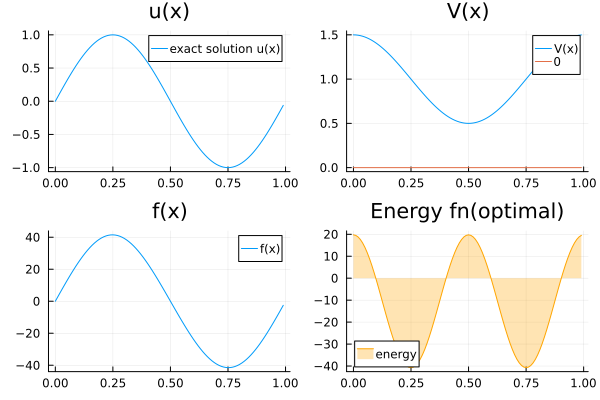

In [5]:
using Plots

u_plot = plot(xx, u_exact, label="exact solution u(x)")
V_plot = plot(xx, [V zeros(N)], 
    labels = ["V(x)" "0"]
)
f_plot = plot(xx, f, label = "f(x)")

## Energy functional
# E(u) = /int_0^1 [1/2 * u'(x)^2 + α/4 * u(x)^4 + V(x)/2 * u(x)^2 - f(x)u] dx
e = 1/2 * (2π .* cos.(2π .*xx)).^2 + α/4 .* u_exact.^4 + V./2 .* u_exact.^2 - f .* u_exact
E = sum(e)/N 
energy_plot = plot(xx, e, label="energy",
fillrange = 0, fillalpha = 0.3, fillcolor = :orange, color= :orange)


plot(u_plot, V_plot, f_plot, energy_plot, layout=(2,2), titles=["u(x)" "V(x)" "f(x)" "Energy fn(optimal)"])

## Optimization

*From here we suppose u in unknown and try to find a u that optimizes the functional*

Because of the discretization it comes back to a N dimensional optimization problem

**Astuces:**

u' can be calculated the following ways: 
- $u'(0) = u'(1)$ condition prompts us to have derivative equal from both ways approaching so we can have 
    $$ u'_i = \frac{u_{i+1} - u_{i-1} }{2h}$$
where the indexing wraps around modulo N
- **Spectral approach**
    We use the DFT, and the derivative in fourier space is easier to calculate

### Method One

#### Derivatives

In [6]:
## First derivative calculation matrix
function diff(N)
    # We need to calculate the u', which is just a linear operator in this case, so we construct a matrix to do that
    D = zeros(N, N)
    h = 1/N
    for i in 1:N
        D[i, mod(i, N)+1] = 1/2h
        D[i, mod(i-2, N)+1 ] = -1/2h
    end
    return D
end

diff (generic function with 1 method)

First Derivative

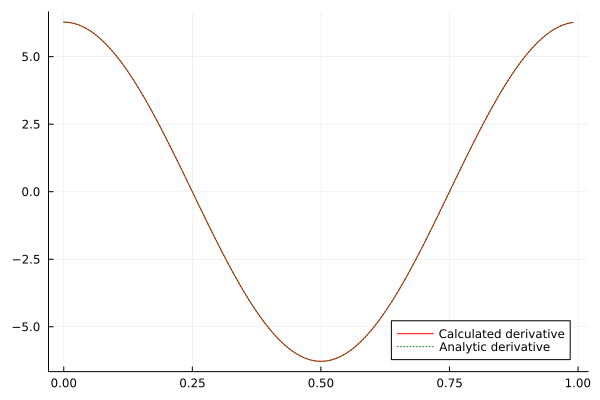

In [7]:
du_calc = diff(N) * u_exact
du_exact = 2π .* cos.(2π .* xx)
# du_calc_plot =plot(xx, du_calc)
# du_exact_plot = plot(xx, du_exact) 
du_plot = plot(xx, [du_calc du_exact], labels=["Calculated derivative" "Analytic derivative"], color=[:red :green], ls= [:solid :dot])
# plot(du_calc_plot, du_exact_plot, du_plot, layout = (2, 2))


In [8]:
## Second derivative calculation matrix
function diff2(N)
    D2 = zeros(N, N)
    h = 1/N
    for i in 1:N
        D2[i, i] = -2/(h^2)
        D2[i, mod(i, N)+1] = 1/(h^2)
        D2[i, mod(i-2, N) +1] = 1/(h^2)
    end
    return D2
end

diff2 (generic function with 1 method)

Second Derivative

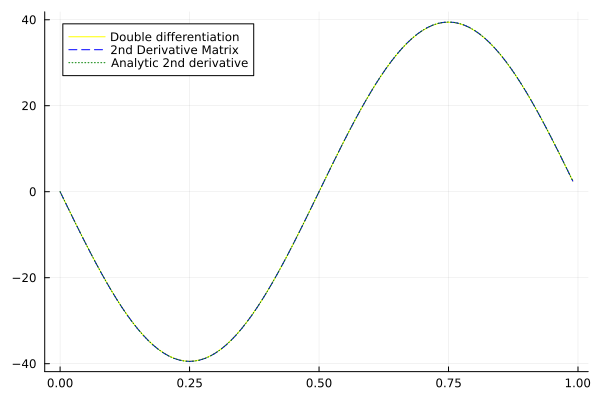

In [9]:
d2u = diff(N) * du_calc
d2u_form = diff2(N) * u_exact
d2u_exact = -4π^2 .* sin.(2π .* xx)
plot(xx, [d2u d2u_form d2u_exact], labels=["Double differentiation" "2nd Derivative Matrix" "Analytic 2nd derivative"], color=[:yellow :blue :green], ls= [:solid :dash :dot])


#### Newtons Method

In [10]:
struct SimpleParams
    N::Int64
    α::Float64
    V::Vector{Float64}
    f::Vector{Float64}
    D2::Matrix{Float64}
end


function F(u, p::SimpleParams)
    return -p.D2* u .+ p.α .* u.^3 + p.V .* u - p.f
end

F (generic function with 1 method)

In [11]:
function Newton_solve(p::SimpleParams, method, n_iter)
    u = zeros(p.N) # u_0
    for i in 1:n_iter
        res = F(u, p)
        J = method(F, p, u)
        step = J \ res
        u = u - step
    end
    return u
end

## A function that stores all the steps of Newton_solve
function Newton_solve_history(p::SimpleParams, method, n_iter)
    U = zeros(n_iter+1, p.N)
    for i in 1:n_iter
        res = F(U[i, :], p)
        J = method(F, p, U[i, :])
        step = J \ res
        U[i+1, :] = U[i, :] - step
    end
    return U
end

Newton_solve_history (generic function with 1 method)

#### Methods for calculating the Jacobian

**Finite differences**
$$ Jv = \frac{F (u + \varepsilon v) − F (u)}{\varepsilon}$$

In [12]:
function finite_differences(F, p, u; eps=1e-8) 
    J = zeros(p.N, p.N)
    for i in 1:p.N
        v = zeros(p.N)
        v[i] = 1
        J[:, i] = (F(u .+ eps * v, p) - F(u, p)) / eps
    end
    return J
end

finite_differences (generic function with 1 method)

**Forward Mode AD**

In [13]:
using Enzyme


function forward_AD(F, p, u)
    J = zeros(p.N, p.N)
    for i in 1:p.N
        v = zeros(p.N)
        v[i] = 1
        (col,) = autodiff(Forward, F, Duplicated(u, v), Const(p))
        J[:, i] = col
    end
    # J = jacobian(Forward, F, Duplicated(u), Const(p), chunk=Val(8))
    # print(J)
    return J
end

forward_AD (generic function with 1 method)

**Reverse Mode AD**

In [14]:

function F_i(u, p, i, F)
    F(u, p)[i]
end

function backward_AD(F, p, u)
    J = zeros(p.N, p.N)
    for i in 1:p.N
        v = zeros(p.N)
        autodiff(Reverse, F_i, Active, Duplicated(u, v), Const(p), Const(i), Const(F))
        J[i, :] = v
    end
    # J = jacobian(Forward, F, Duplicated(u), Const(p), chunk=Val(8))
    # print(J)
    return J
end

backward_AD (generic function with 1 method)

#### Evaluating performance

**Visualizing newton steps**

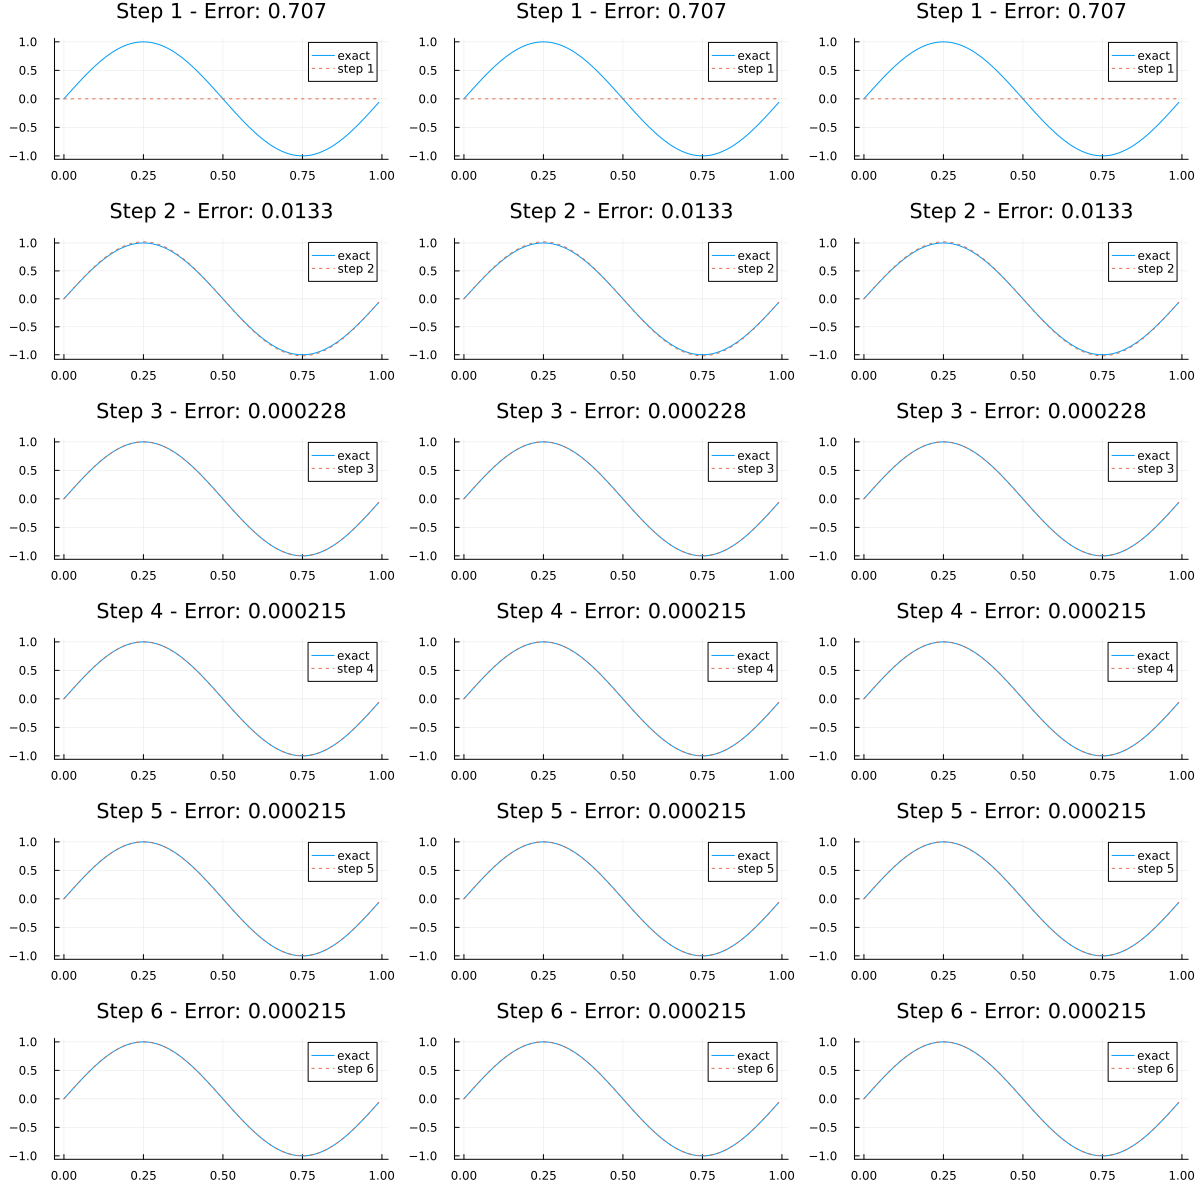

In [15]:
p_basic = SimpleParams(N, α, V, f, diff2(N))
steps = 5

solution_steps_fd = Newton_solve_history(p_basic, finite_differences, steps)
solution_steps_forwardAD = Newton_solve_history(p_basic, forward_AD, steps)
solution_steps_backwardAD = Newton_solve_history(p_basic, backward_AD, steps)

plots_fd = Vector{Any}(undef, steps+1)
plots_fad  = Vector{Any}(undef, steps+1)
plots_bad  = Vector{Any}(undef, steps+1)

for i in 1:steps+1
    error_fd = l2norm(solution_steps_fd[i, :] - u_exact)
    plots_fd[i] = plot(xx, [u_exact, solution_steps_fd[i, :]], ls=[:solid :dot], label=["exact" "step $i"], title="Step $i - Error: $(round(error_fd, sigdigits=3))")

    error_fad = l2norm(solution_steps_forwardAD[i, :] - u_exact)
    plots_fad[i] = plot(xx, [u_exact, solution_steps_forwardAD[i, :]], ls=[:solid :dot], label=["exact" "step $i"], title="Step $i - Error: $(round(error_fad, sigdigits=3))")

    error_bad = l2norm(solution_steps_backwardAD[i, :] - u_exact)
    plots_bad[i] = plot(xx, [u_exact, solution_steps_backwardAD[i, :]], ls=[:solid :dot], label=["exact" "step $i"], title="Step $i - Error: $(round(error_bad, sigdigits=3))")
end

plot_fd = plot(plots_fd..., layout=(steps+1, 1), size=(400, 200*(steps+1)))
plot_fad = plot(plots_fad..., layout=(steps+1, 1), size=(400, 200*(steps+1)))
plot_bad =  plot(plots_bad..., layout=(steps+1, 1), size=(400, 200*(steps+1)))


plot(plot_fd, plot_fad, plot_bad, layout= (1, 3), size=(1200, 200*(steps+1)))

**Timing**

In [16]:
p_basic = SimpleParams(N, α, V, f, diff2(N))

time_fd = @elapsed u_solve = Newton_solve(p_basic, finite_differences, 5)
time_fad = @elapsed u_forward = Newton_solve(p_basic, forward_AD, 5)
time_bad = @elapsed u_backward = Newton_solve(p_basic, backward_AD, 5)

data = [
    "Finite Differences"  time_fd l2norm(u_solve - u_exact);
    "Forward AD"  time_fad l2norm(u_forward - u_exact);
    "Backward AD"  time_bad l2norm(u_backward - u_exact);
]

pretty_table(data,
    column_labels = ["Method", "Time (s)", "L² Error"],
    formatters = [(v, i, j) -> j > 1 ? @sprintf("%.5e", v) : v])

┌────────────────────┬─────────────┬─────────────┐
│             Method │    Time (s) │    L² Error │
├────────────────────┼─────────────┼─────────────┤
│ Finite Differences │ 7.96434e-02 │ 2.14979e-04 │
│         Forward AD │ 4.51615e-02 │ 2.14979e-04 │
│        Backward AD │ 1.64367e-01 │ 2.14979e-04 │
└────────────────────┴─────────────┴─────────────┘


**Scaling**

— 5 Iterations —
┌────────┬──────────┬──────────┬─────────────────┬──────────────────┬───────────
│      N │  FD Time │ FD Error │ Forward AD Time │ Forward AD Error │ Backward ⋯
├────────┼──────────┼──────────┼─────────────────┼──────────────────┼───────────
│    5.0 │ 9.36e-05 │ 9.15e-02 │        1.77e-04 │         9.15e-02 │          ⋯
│   10.0 │ 7.25e-05 │ 2.18e-02 │        8.45e-05 │         2.18e-02 │          ⋯
│  100.0 │ 1.46e-02 │ 2.15e-04 │        1.00e+00 │         2.15e-04 │          ⋯
│  500.0 │ 4.64e+00 │ 8.60e-06 │        1.00e+01 │         8.60e-06 │          ⋯
│ 1000.0 │ 3.69e+01 │ 2.15e-06 │        6.65e+01 │         2.15e-06 │          ⋯
└────────┴──────────┴──────────┴─────────────────┴──────────────────┴───────────
                                                               2 columns omitted


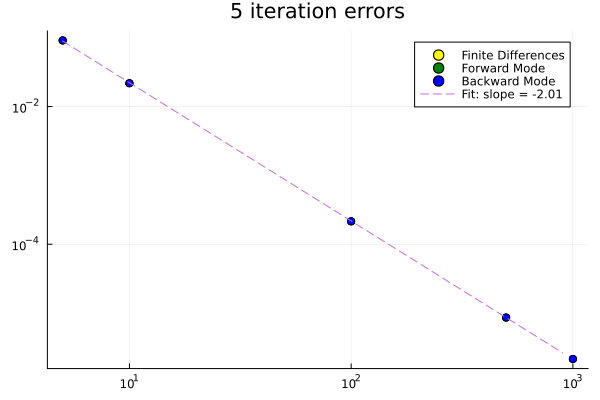

In [ ]:
function create_params(N)
    xx = linspace(0, 1, N)

    u_exact = sin.(2pi .* xx)
    # α - a real
    α = 1.
    # V(x) - a function
    V = 1.0 .+ 0.5 .* cos.(2π .* xx)
    #f(x) - a function
    f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact
    
    return SimpleParams(N, α, V, f, diff2(N))
end


N_test = [5, 10, 100, 500, 1000]
p_test = map(create_params, N_test)

errs_5iter = zeros(length(N_test), 3)
data_5iter = Matrix{Any}(undef, length(N_test), 7)

for (i, p) in enumerate(p_test)
    u_ref = sin.(2π .* linspace(0, 1, p.N))

    t_fd  = @elapsed u_fd  = Newton_solve(p, finite_differences, 5)
    t_fad = @elapsed u_fad = Newton_solve(p, forward_AD, 5)
    t_bad = @elapsed u_bad = Newton_solve(p, backward_AD, 5)
    errs_5iter[i, :] = [l2norm(u_fd - u_ref), l2norm(u_fad - u_ref), l2norm(u_bad - u_ref)]
    data_5iter[i, :] = [p.N, t_fd, errs_5iter[i,1], t_fad, errs_5iter[i,2], t_bad, errs_5iter[i,3]]
end

headers = ["N", "FD Time", "FD Error", "Forward AD Time", "Forward AD Error", "Backward AD Time", "Backward AD Error"]
fmt = [(v, i, j) -> j > 1 ? @sprintf("%.2e", v) : v]

println("— 5 Iterations —")
pretty_table(data_5iter, column_labels=headers, formatters=fmt,  display_size=(-1,-1) )


p_fit = fit(log10.(Float64.(N_test)), log10.(errs_5iter[:, 1]), 1)
slope = coeffs(p_fit)[2]

N_dense = linspace(N_test[1], N_test[end], 10)
line = 10 .^ p_fit.(log10.(N_dense))

points = scatter(N_test, [errs_5iter[:, 1] errs_5iter[:, 2] errs_5iter[:, 3]], color = [:yellow :green :blue], label = ["Finite Differences" "Forward Mode" "Backward Mode"], xscale=:log10, yscale=:log10, title = "5 iteration errors")

plot!(points, N_dense, line, ls=:dash, label = "Fit: slope = $(round(slope, digits=2))")


### Spectral Method

The key idea of this method is that we use the fact that the solution is periodic, and for a periodic function we can calculate the derivative more easily after a fourier transform, it becomes just a multiplication!

In [25]:
using FFTW

function diff_fourier(u, ks)
    u_trans = fft(u)
    real(ifft(im .* ks .* u_trans))
end

function diff2_fourier(u, ks)
    real(ifft(- ks.^2 .* fft(u)))
end

diff2_fourier (generic function with 1 method)

In [ ]:
xx = linspace(0, 1, N)
u_exact = sin.(2pi .* xx)

time_fourier = @elapsed du_four = diff_fourier(u_exact,  2π .* fftfreq(N, N))
time_fd = @elapsed du_calc = diff(N) * u_exact

time_fourier_2 = @elapsed du2_four = diff2_fourier(u_exact, 2π .* fftfreq(N, N))
time_fd_2 = @elapsed du2_calc = diff2(N) * u_exact


du_exact = 2π .* cos.(2π .* xx)
du2_exact = -4π^2 .* sin.(2π .* xx)

data = [
    "Finite Differences"  time_fd l2norm(du_calc - du_exact) time_fd_2 l2norm(du2_calc - du2_exact) ;
    "Fourier transform"  time_fourier l2norm(du_four - du_exact) time_fourier_2 l2norm(du2_four - du2_exact);
]

pretty_table(data,
    column_labels = ["Method", "du/dx Time (s)", "du/dx L² Error", "du/dx² Time (s)", "du/dx² L² Error"],
    formatters = [(v, i, j) -> j > 1 ? @sprintf("%.5e", v) : v], display_size=(-1,-1) )

┌────────────────────┬────────────────┬────────────────┬─────────────────┬─────────────────┐
│             Method │ du/dx Time (s) │ du/dx L² Error │ du/dx² Time (s) │ du/dx² L² Error │
├────────────────────┼────────────────┼────────────────┼─────────────────┼─────────────────┤
│ Finite Differences │    5.52230e-05 │    2.92272e-03 │     6.84090e-05 │     9.18261e-03 │
│  Fourier transform │    1.44003e-04 │    3.82783e-14 │     1.28382e-04 │     1.22459e-11 │
└────────────────────┴────────────────┴────────────────┴─────────────────┴─────────────────┘


### Revised Newton method

In [30]:
struct FourierParams
    N::Int64
    α::Float64
    V::Vector{Float64}
    f::Vector{Float64}
    Ks::Vector{Float64}
end


function F_fourier(u, p::FourierParams)
    return -diff2_fourier(u, p.Ks) + p.α .* u.^3 + p.V .* u - p.f
end

function create_fparams(N)
    xx = linspace(0, 1, N)

    u_exact = sin.(2pi .* xx)
    # α - a real
    α = 1.
    # V(x) - a function
    V = 1.0 .+ 0.5 .* cos.(2π .* xx)
    #f(x) - a function
    f = 4π^2*sin.(2π .* xx) + α .* u_exact.^3 + V .* u_exact
    
    return FourierParams(N, α, V, f,  collect(2π .* fftfreq(N, N)))
end

create_fparams (generic function with 1 method)

Calculating now the Jacobian we will get a dense matrix, so solving it directly will be very computationally difficult
We opt for the following approach:

The only way we use the J matrix is to calculate $J^-1res$, or in other words 
find delta u such that
$$J \delta u = res(u)$$

having in mind that J is the jacobian, we find that J is the operator 
$$J(u) \delta u = -\delta u'' + 3 \alpha u^2 \delta u + V \delta u$$

we can consider the function 
$$f: \delta u \mapsto -\delta u'' + 3 \alpha u^2 \delta u + V \delta u$$

As the jacobian rests a linear operator, this function is also a linear map, we can use a Krylov method to solve for $f(x) = res(u)$

In [31]:
using Krylov, LinearOperators

function Newton_solve_fourier(p::FourierParams, n_iter; verbose=false, tol=1e-16)
    u = zeros(p.N) # u_0
    for i in 1:n_iter
        res = F_fourier(u, p)
        L = (result, du) -> result .= -diff2_fourier(du, p.Ks) + 3 * p.α .* u .^2 .* du .+ p.V .* du
        op = LinearOperator(Float64, p.N, p.N, true, true, L)
        step, stats = cg(op, res)
        if(verbose)
            println("Iteration: ", i,",\n stats: ", stats )
        end
        u = u - step
        if(l2norm(step)<tol)
            if(verbose)
                println("Took ", i, "iterations to converge")
            end
            return u
        end
    end
    return u
end

Newton_solve_fourier (generic function with 1 method)

In [32]:
Newton_solve_fourier(create_fparams(100), 10, verbose=true)
print("")

Iteration: 1,
 stats: SimpleStats
 niter: 12
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 2.50μs
 timer: 285.27ms
 status: solution good enough given atol and rtol

Iteration: 2,
 stats: SimpleStats
 niter: 53
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 1.45μs
 timer: 1.53ms
 status: solution good enough given atol and rtol

Iteration: 3,
 stats: SimpleStats
 niter: 50
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 1.05μs
 timer: 1.28ms
 status: solution good enough given atol and rtol

Iteration: 4,
 stats: SimpleStats
 niter: 0
 solved: true
 inconsistent: false
 indefinite: false
 npcCount: 0
 residuals: []
 Aresiduals: []
 κ₂(A): []
 allocation timer: 0.73μs
 timer: 1.47μs
 status: solution good enough given atol and rtol

Took 4iteration

┌────────┬──────────┬──────────┬────────────────────┬─────────────────────┐
│      N │  FD Time │ FD Error │ Fourier Solve Time │ Fourier Solve Error │
├────────┼──────────┼──────────┼────────────────────┼─────────────────────┤
│    5.0 │ 8.63e-05 │ 9.15e-02 │           3.16e-04 │            1.50e-11 │
│   10.0 │ 9.23e-05 │ 2.18e-02 │           2.54e-04 │            1.35e-11 │
│  100.0 │ 5.39e-02 │ 2.15e-04 │           3.50e-03 │            1.35e-11 │
│  500.0 │ 3.26e+00 │ 8.60e-06 │           4.83e-02 │            1.21e-13 │
│ 1000.0 │ 3.61e+01 │ 2.15e-06 │           1.81e-01 │            1.58e-14 │
└────────┴──────────┴──────────┴────────────────────┴─────────────────────┘


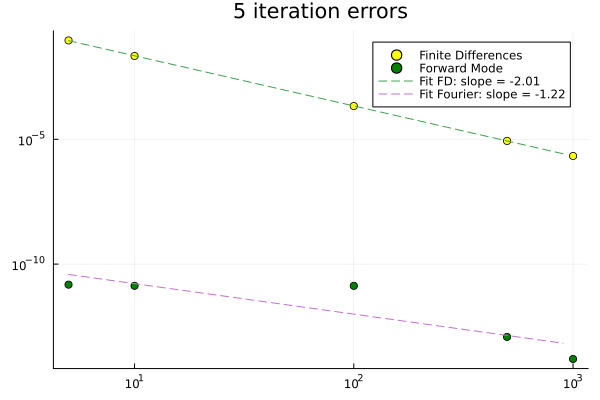

In [36]:
N_test = [5, 10, 100, 500, 1000]
p_test = map(create_params, N_test)

errs_5iter = zeros(length(N_test), 2)
data_5iter = Matrix{Any}(undef, length(N_test), 5)

for (i, p) in enumerate(p_test)
    u_ref = sin.(2π .* linspace(0, 1, p.N))

    t_fd  = @elapsed u_fd  = Newton_solve(p, finite_differences, 5)
    t_four = @elapsed u_fourier = Newton_solve_fourier(create_fparams(p.N), 5)

    errs_5iter[i, :] = [l2norm(u_fd - u_ref), l2norm(u_fourier - u_ref)]
    data_5iter[i, :] = [p.N, t_fd, errs_5iter[i,1], t_four, errs_5iter[i,2]]
end

headers = ["N", "FD Time", "FD Error", "Fourier Solve Time", "Fourier Solve Error"]
fmt = [(v, i, j) -> j > 1 ? @sprintf("%.2e", v) : v]

pretty_table(data_5iter, column_labels=headers, formatters=fmt,  display_size=(-1,-1) )


p_fit = fit(log10.(Float64.(N_test)), log10.(errs_5iter[:, 1]), 1)
slope = coeffs(p_fit)[2]

p_fit2 = fit(log10.(Float64.(N_test)), log10.(errs_5iter[:, 2]), 1)
slope2 = coeffs(p_fit2)[2]


N_dense = linspace(N_test[1], N_test[end], 10)
line1 = 10 .^ p_fit.(log10.(N_dense))
line2 = 10 .^ p_fit2.(log10.(N_dense))

points = scatter(N_test, [errs_5iter[:, 1] errs_5iter[:, 2]], color = [:yellow :green :blue], label = ["Finite Differences" "Forward Mode" "Backward Mode"], xscale=:log10, yscale=:log10, title = "5 iteration errors")

plot!(points, N_dense, [line line2], ls=:dash, label = ["Fit FD: slope = $(round(slope, digits=2))" "Fit Fourier: slope = $(round(slope2, digits=2))"])

The new method is orders of magnitude more accurate than the previous methods, and faster to compute. Lets see how the error progresses through iterations for this method

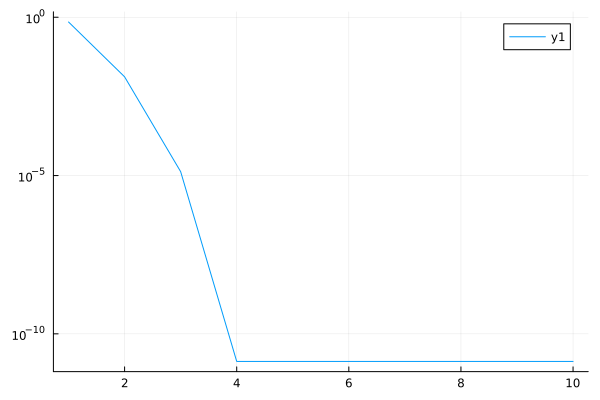

print device already activated


In [39]:
function Newton_solve_fourier_history(p::FourierParams, n_iter; verbose=false, tol=1e-16)
    U = zeros(n_iter+1, p.N)
    for i in 1:n_iter
        res = F_fourier(U[i, :], p)
        L = (result, du) -> result .= -diff2_fourier(du, p.Ks) + 3 * p.α .* U[i, :] .^2 .* du .+ p.V .* du
        op = LinearOperator(Float64, p.N, p.N, true, true, L)
        step, stats = cg(op, res)
        if(verbose)
            println("Iteration: ", i,",\n stats: ", stats )
        end
        U[i+1, :] = U[i, :] - step
    end
    return U
end

p = create_fparams(N)
u_fourier_history = Newton_solve_fourier_history(p, 10)

errors = zeros(10)
for i in 1:10
    errors[i]  = l2norm(u_fourier_history[i, :] - u_exact)
end

plot(1:10, errors, yscale=:log10)

### Adding preconditioning for the Krylov Solver

The condition number for the linear operator L grows quadratically with N, so the number of solve steps to solve using the conjugate gradient method grows linearly. To tackle this issue we introduce a preconditionner

$$
L(\delta u) = -\frac{\delta u}{dx^2} + 3 α u^2 \delta u + V \delta u
$$

The second derivative is easy to invert, so we use it as the preconditionner.
There raises an issue with using it directly as the preconditionner, as the matrix can become not positive definite, so the conjugate gradient solve would fail. For this we add a constant c 
$$ c = \frac{1}{N}\sum_i (3\alpha u_i^2 + V_i)$$


$$P^{-1}L \delta u = P^{-1} \text{res}$$

where $P  = -\frac{\delta u}{dx^2} +  \frac{1}{N}\sum_i (3\alpha u_i^2 + V_i)$

In [ ]:
function Newton_solve_fourier_preconditioned(p::FourierParams, n_iter; tol=1e-16)
    u = zeros(p.N) # u_0
    for i in 1:n_iter
        res = F_fourier(u, p)
        L = (result, du) -> result .= -diff2_fourier(du, p.Ks) + 3 * p.α .* u .^2 .* du .+ p.V .* du
        op = LinearOperator(Float64, p.N, p.N, true, true, L)
        c = sum(3 * p.α .* u .^2 .+ p.V) / p.N
        P = (out, v) -> out .= real(ifft(fft(v) ./ (p.Ks.^2 .+ c)))
        P_op = LinearOperator(Float64, p.N, p.N, true, true, P)

        # step, stats = cg(op, res)
        step, precond_stats = cg(op, res, M=P_op)
        u = u - step
        if(l2norm(step2)<tol)
            return u
        end
    end
    return u
end

Newton_solve_fourier_preconditioned (generic function with 1 method)

┌────────┬───────────────────────┬────────────────────┐
│      N │ CG iters (no precond) │ CG iters (precond) │
├────────┼───────────────────────┼────────────────────┤
│     64 │                     8 │                  3 │
│    128 │                    15 │                  3 │
│    256 │                    31 │                  3 │
│    512 │                    59 │                  3 │
│   1024 │                   115 │                  3 │
│   2048 │                   231 │                  3 │
│   4096 │                   468 │                  3 │
│   8192 │                  1004 │                  3 │
│  16384 │                  1979 │                  3 │
│  32768 │                  4094 │                  3 │
│  65536 │                  8448 │                  3 │
│ 131072 │                 17404 │                  3 │
│ 262144 │                 38002 │                  3 │
└────────┴───────────────────────┴────────────────────┘


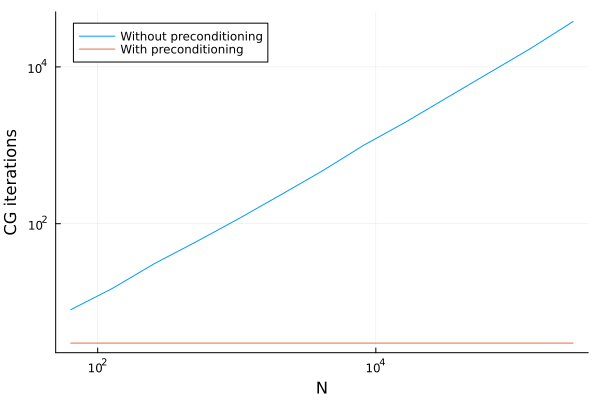

In [41]:
function Newton_step_preconditioned_test(p::FourierParams; tol=1e-16)
    u = zeros(p.N) # u_0
    res = F_fourier(u, p)
    L = (result, du) -> result .= -diff2_fourier(du, p.Ks) + 3 * p.α .* u .^2 .* du .+ p.V .* du
    op = LinearOperator(Float64, p.N, p.N, true, true, L)
    c = sum(3 * p.α .* u .^2 .+ p.V) / p.N
    P = (out, v) -> out .= real(ifft(fft(v) ./ (p.Ks.^2 .+ c)))
    P_op = LinearOperator(Float64, p.N, p.N, true, true, P)

    step, precond_stats = cg(op, res, M=P_op)
    _, stats = cg(op, res)
    return [stats.niter,precond_stats.niter]
end


Ns = 2 .^ collect(6:18)
n_iter = zeros(Int, length(Ns), 2)

for (i, N) in enumerate(Ns)
    n_iter[i, :] = Newton_step_preconditioned_test(create_fparams(N))
end

pretty_table(
    hcat(Ns, n_iter),
    column_labels = ["N", "CG iters (no precond)", "CG iters (precond)"])

plot(Ns, [n_iter[:, 1] n_iter[:, 2]],
    label = ["Without preconditioning" "With preconditioning"],
    xscale = :log10, yscale = :log10,
    xlabel = "N", ylabel = "CG iterations")

## Error Analysis

The total error $\|u_\text{computed} - u^\star\|$ decomposes into:

- Discretization error — from approximating the PDE on a finite grid. Unavoidable for a given N
- Newton iteration error — from stopping Newton before convergence. Decays quadratically each iteration. Controlled by tolerance.
- Roundoff — floating-point arithmetic gives a floor at $\sim 10^{-13}$($10^{-16}$ for each operation, accumulating with iterations)

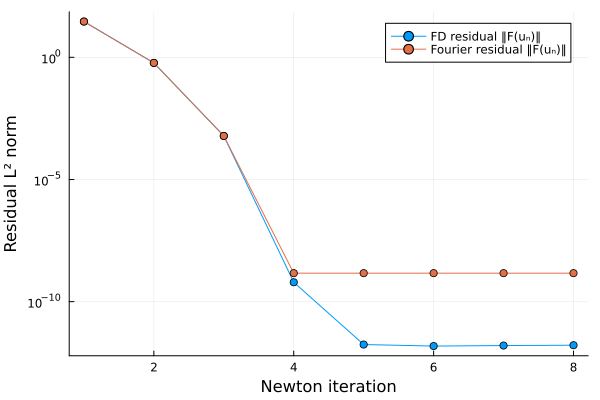

In [42]:
# FD residual history
res_fd = Float64[]
u = zeros(N)
for _ in 1:8
    r = F(u, p_basic)
    push!(res_fd, l2norm(r))
    u -= forward_AD(F, p_basic, u) \ r
end

# Fourier residual history  
res_four = Float64[]
u = zeros(N)
p = create_fparams(N)
for _ in 1:8
    r = F_fourier(u, p)
    push!(res_four, l2norm(r))
    L = (out, du) -> out .= -diff2_fourier(du, p.Ks) .+ 3p.α .* u.^2 .* du .+ p.V .* du
    u -= cg(LinearOperator(Float64, N, N, true, true, L), r)[1]
end

plot(1:8, [res_fd res_four], yscale=:log10,
    label=["FD residual ‖F(uₙ)‖" "Fourier residual ‖F(uₙ)‖"],
    xlabel="Newton iteration", ylabel="Residual L² norm",
    marker=:circle)

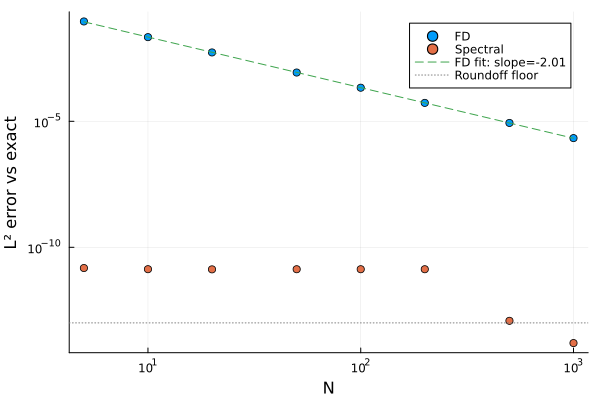

In [43]:
N_vals = [5, 10, 20, 50, 100, 200, 500, 1000]
err_fd   = Float64[]
err_four = Float64[]

for N in N_vals
    u_ref = sin.(2π .* linspace(0, 1, N))
    push!(err_fd,   l2norm(Newton_solve(create_params(N), forward_AD, 10) .- u_ref))
    push!(err_four, l2norm(Newton_solve_fourier(create_fparams(N), 10) .- u_ref))
end

p_fd = fit(log10.(Float64.(N_vals)), log10.(err_fd), 1)

plt = scatter(N_vals, [err_fd err_four],
    xscale=:log10, yscale=:log10,
    label=["FD" "Spectral"], marker=:circle,
    xlabel="N", ylabel="L² error vs exact")

N_dense = 10 .^ range(log10(5), log10(1000), length=200)
plot!(plt, N_dense, 10 .^ p_fd.(log10.(N_dense)),
    ls=:dash, label="FD fit: slope=$(round(coeffs(p_fd)[2], digits=2))")
hline!(plt, [1e-13], ls=:dot, color=:gray, label="Roundoff floor")